# TFIM 1D: límite termodinámico vs $N=12$ espines

Comparación entre las expresiones exactas en el límite $N\to\infty$ (obtenidas mediante la transformación de Jordan-Wigner y diagonalización de Bogoliubov) y los resultados de diagonalización exacta para una cadena de $N=12$ espines con PBC.

**Observables calculados:** energía del estado fundamental $E_0/N$, magnetización $\langle|m|\rangle$ y susceptibilidad $N\cdot\text{Var}(m)$.

## 0. Imports y configuración

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import eigsh

N     = 12
J     = 1.0
BETA  = 1.0

g_cont = np.linspace(0.02, 3.0, 600)   # curva continua
g_ed   = np.concatenate([                # puntos ED: más densos cerca de gc
    np.linspace(0.1,  0.8,  8),
    np.linspace(0.85, 1.15, 14),
    np.linspace(1.2,  3.0,  10),
])

## 1. Precomputar estructura del Hamiltoniano

In [9]:
dim      = 2**N
mag_vals = np.array([
    sum(1 - 2*((s >> i) & 1) for i in range(N)) / N
    for s in range(dim)
])

diag_base = np.zeros(dim)
for s in range(dim):
    for i in range(N):
        j  = (i+1) % N
        si = 1 - 2*((s >> i) & 1)
        sj = 1 - 2*((s >> j) & 1)
        diag_base[s] += -J * si * sj

## 2. Diagonalización exacta (sparse)

In [10]:
def exact_diag(g):
    H = lil_matrix((dim, dim), dtype=float)
    h = g * J
    for s in range(dim):
        H[s, s] = diag_base[s]
        for i in range(N):
            H[s, s ^ (1 << i)] -= h
    H = H.tocsr()
    vals, vecs = eigsh(H, k=2, which='SA')
    idx  = np.argsort(vals)
    vals = vals[idx]; vecs = vecs[:, idx]
    probs = vecs[:, 0]**2
    m1  = np.sum(probs * np.abs(mag_vals))
    m2  = np.sum(probs * mag_vals**2)
    return {
        "E0":  vals[0] / N,
        "m":   m1,
        "chi": BETA * N * (m2 - m1**2),
        "gap": (vals[1] - vals[0]) / N,
    }

## 3. Límite termodinámico: funciones analíticas

In [11]:
def energy_thermo(g):
    """E0/N = -1/π ∫_0^π √(1 + g² - 2g cos k) dk"""
    I, _ = integrate.quad(lambda k: np.sqrt(1 + g**2 - 2*g*np.cos(k)), 0, np.pi)
    return -I / np.pi

def mag_thermo(g_arr):
    """⟨|m|⟩ = (1-g²)^{1/8} para g<1, 0 para g≥1  (exponente crítico β=1/8)"""
    return np.where(g_arr < 1.0, np.maximum(1.0 - g_arr**2, 0.0)**(1.0/8.0), 0.0)

def gap_thermo(g_arr):
    """Δ = |1 - g| en el límite termodinámico"""
    return np.abs(1.0 - g_arr)

def gap_finite(g, N):
    """
    Gap para N finito.
    Sector NS (momentos semienteros): estado fundamental.
    Sector R  (momentos enteros):     estados de pared de dominio (relevantes en fase FM).
    Gap = min(E1_NS, E1_R) - E0_NS, normalizado por N.
    """
    ks_ns  = np.pi / N * np.arange(-(N-1), N, 2)
    eps_ns = np.sqrt(1 + g**2 - 2*g*np.cos(ks_ns))
    E0_ns  = -eps_ns.sum()
    E1_ns  = E0_ns + 2*eps_ns.min()   # crear una cuasipartícula en k_min

    ks_r   = 2*np.pi / N * np.arange(-N//2+1, N//2+1)
    eps_r  = np.sqrt(1 + g**2 - 2*g*np.cos(ks_r))
    E1_r   = -eps_r.sum() + 2*eps_r.min()

    return (min(E1_ns, E1_r) - E0_ns) / N

## 4. Cálculo de observables

In [12]:
print("Calculando límite termodinámico...")
E_inf   = np.array([energy_thermo(g) for g in g_cont])
m_inf   = mag_thermo(g_cont)
gap_inf = gap_thermo(g_cont)
gap_fin = np.array([gap_finite(g, N) for g in g_cont])

print(f"Diagonalización exacta ({len(g_ed)} puntos)...")
ed = [exact_diag(g) for g in g_ed]
E_ed   = np.array([r["E0"]  for r in ed])
m_ed   = np.array([r["m"]   for r in ed])
chi_ed = np.array([r["chi"] for r in ed])
gap_ed = np.array([r["gap"] for r in ed])
print("Listo.")

# Guia visual de chi ~ |g-1|^(-7/4) en el limite termodinamico, normalizada con la ED
def chi_guide(g_arr, g_ref, chi_ref):
    norm = chi_ref / np.abs(g_ref - 1.0)**(-7/4)
    return norm * np.abs(g_arr - 1.0)**(-7/4)

g_ref_pm  = 1.5
g_ref_fm  = 0.7
chi_pm_ref = chi_ed[np.argmin(np.abs(g_ed - g_ref_pm))]
chi_fm_ref = chi_ed[np.argmin(np.abs(g_ed - g_ref_fm))]

g_pm = g_cont[g_cont > 1.08]
g_fm = g_cont[(g_cont > 0.1) & (g_cont < 0.92)]
chi_pm = chi_guide(g_pm, g_ref_pm, chi_pm_ref)
chi_fm = chi_guide(g_fm, g_ref_fm, chi_fm_ref)

Calculando límite termodinámico...
Diagonalización exacta (32 puntos)...
Listo.


## 5. Figura: comparación $N$ finito vs termodinámico

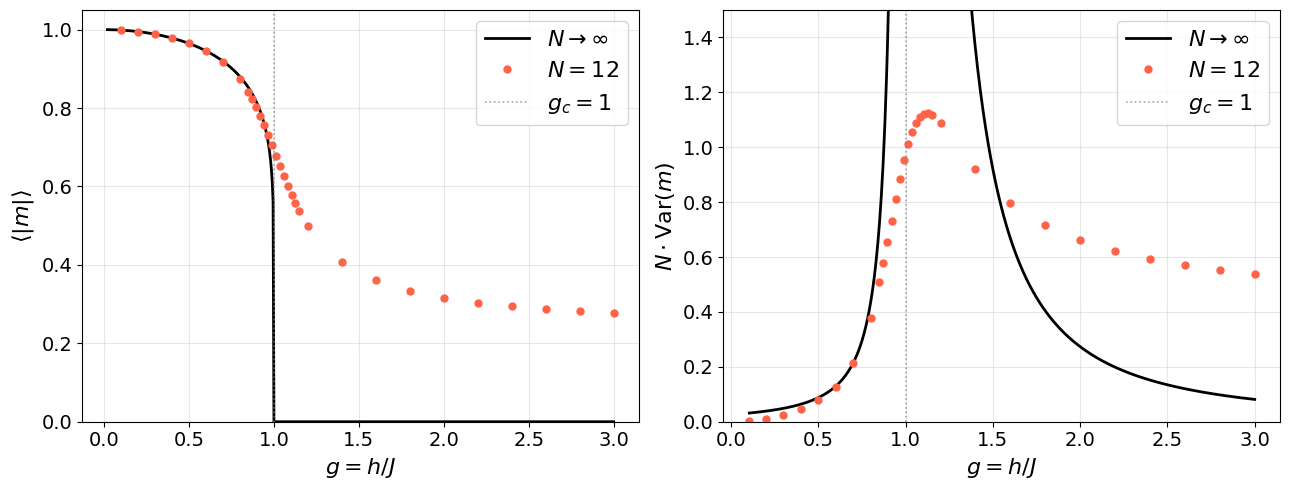

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

kw_inf = dict(color="k",      lw=2, label=r"$N\to\infty$")
kw_ed  = dict(color="tomato", lw=0, marker="o", ms=5,
              label=fr"$N={N}$")

def add_vline(ax):
    ax.axvline(1.0, color="gray", ls=":", lw=1.2, alpha=0.7, label=r"$g_c = 1$")

ax = axes[0]
ax.plot(g_cont, m_inf, **kw_inf)
ax.plot(g_ed,   m_ed,  **kw_ed)
add_vline(ax)
ax.set_xlabel(r"$g = h/J$", fontsize=16)
ax.set_ylabel(r"$\langle|m|\rangle$", fontsize=16)
ax.legend(fontsize=16)
ax.grid(alpha=0.3)
ax.tick_params(axis='both', labelsize=16)
ax.set_ylim(0, 1.05)

# Rama izquierda solo cerca de gc para no alejarse visualmente de la curva de N finito
ax = axes[1]
g_pm = g_cont[g_cont > 1.05]                          # rama derecha: todo g > gc
g_fm = g_cont[(g_cont > 0.10) & (g_cont < 0.975)]     # rama izquierda: solo cerca de gc
ax.plot(g_pm, chi_guide(g_pm, g_ref_pm, chi_pm_ref),
        color="k", lw=2, label=r"$N\to\infty$")
ax.plot(g_fm, chi_guide(g_fm, g_ref_fm, chi_fm_ref),
        color="k", lw=2)
ax.plot(g_ed, chi_ed, **kw_ed)
add_vline(ax)
ax.set_xlabel(r"$g = h/J$", fontsize=16)
ax.set_ylabel(r"$\chi$", fontsize=16)
ax.legend(fontsize=16)
ax.grid(alpha=0.3)
ax.tick_params(axis='both', labelsize=16)
ax.set_ylim(0, 1.5)

plt.tight_layout()


## 6. Figuras anteriores individuales ##

(0.0, 1.5)

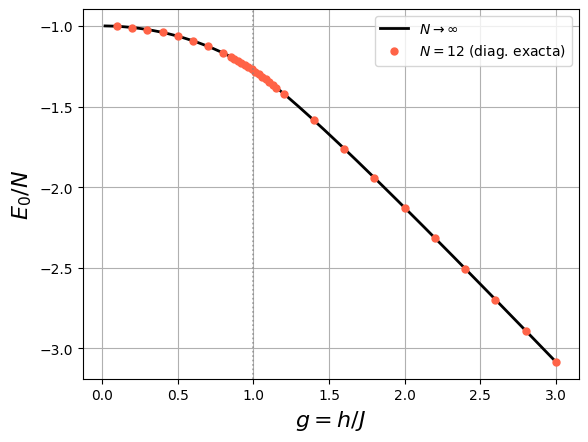

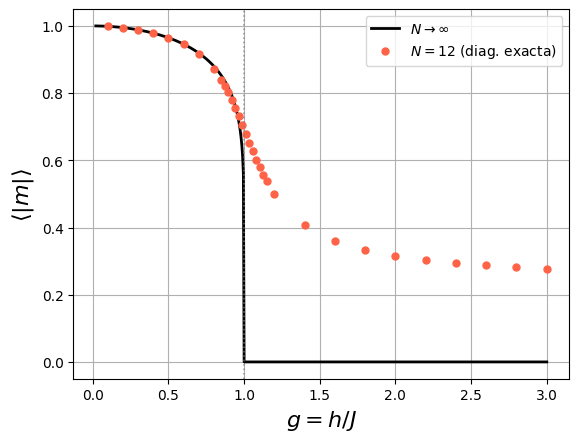

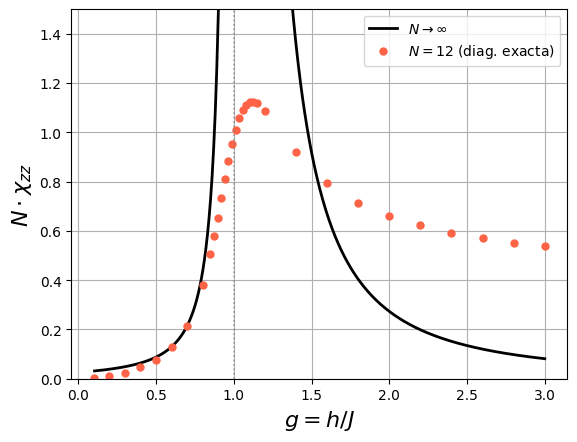

In [14]:
kw_inf = dict(color="k",      lw=2, label=r"$N\to\infty$")
kw_ed  = dict(color="tomato", lw=0, marker="o", ms=5,
              label=fr"$N={N}$ (diag. exacta)")

def add_vline(ax):
    ax.axvline(1.0, color="gray", ls=":", lw=1.2, alpha=0.7, label=r"$g_c = 1$")

plt.figure(1)
plt.plot(g_cont, E_inf, **kw_inf,)
plt.plot(g_ed,   E_ed,  **kw_ed)
plt.xlabel(r"$g = h/J$", fontsize=16)
plt.ylabel(r"$E_0/N$",   fontsize=16)
plt.legend()
plt.grid()
add_vline(plt.gca())


plt.figure(2)
plt.plot(g_cont, m_inf, **kw_inf)
plt.plot(g_ed,   m_ed,  **kw_ed)

plt.xlabel(r"$g = h/J$", fontsize=16)
plt.ylabel(r"$\langle|m|\rangle$", fontsize=16)
plt.legend()
plt.grid()
add_vline(plt.gca())

plt.figure(3)
g_pm = g_cont[g_cont > 1.05]                          # rama derecha: todo g > gc
g_fm = g_cont[(g_cont > 0.10) & (g_cont < 0.975)]     # rama izquierda: solo cerca de gc
plt.plot(g_pm, chi_guide(g_pm, g_ref_pm, chi_pm_ref),
         color="k", lw=2, label=r"$N\to\infty$")
plt.plot(g_fm, chi_guide(g_fm, g_ref_fm, chi_fm_ref),
            color="k", lw=2)
plt.plot(g_ed, chi_ed, **kw_ed)
plt.xlabel(r"$g = h/J$", fontsize=16)
plt.ylabel(r"$N\cdot\chi_{zz}$", fontsize=16)
plt.legend()
add_vline(plt.gca())
plt.grid()
plt.ylim(0, 1.5)